In [1]:
from utils.inspect_data_helpers import *
from hierarchies.hierarchies import get_hierarchy_tree
import json
import os

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)
from typing import Dict, Optional

#### Loss Dynamics

In [33]:
def plot_loss_curves(csv_paths, labels=None, figsize=(8, 5)):
    """
    Plot train and validation loss curves from one or more metrics.csv files.

    Parameters
    ----------
    csv_paths : list[str]
        Paths to metrics.csv files.

    labels : list[str], optional
        Names for the experiments.
        Defaults to file names.

    figsize : tuple
        Matplotlib figure size.
    """

    if labels is None:
        labels = [f"Run {i+1}" for i in range(len(csv_paths))]

    plt.figure(figsize=figsize)

    for csv_path, label in zip(csv_paths, labels):
        df = pd.read_csv(csv_path)

        epochs = (
            df["epoch"]
            if "epoch" in df.columns
            else range(1, len(df) + 1)
        )

        plt.plot(
            epochs,
            df["train_loss"],
            linestyle="-",
            label=f"{label} Train"
        )

        plt.plot(
            epochs,
            df["val_loss"],
            linestyle="--",
            label=f"{label} Test"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Dynamics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.ylim(0, 3)
    plt.show()

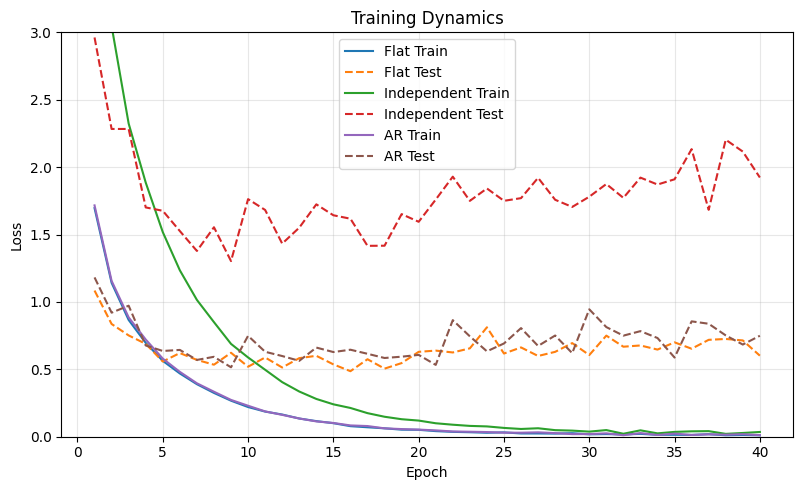

In [34]:
plot_loss_curves(
    [
        "outputs_local/outputs2/flat_final_test_fold10/metrics.csv",
        "outputs_local/outputs2/independent_hierarchy_final_test_fold10/metrics.csv",
        "outputs_local/outputs2/ar_hierarchy_masked_final_test_fold10/metrics.csv",
    ],
    labels=[
        "Flat",
        "Independent",
        "AR"
    ]
)

#### Hierarchical Error Breakdown

In [42]:
def parse_path(path):
    if isinstance(path, list):
        return path
    return ast.literal_eval(path)


def parse_bool(value):
    if isinstance(value, bool):
        return value

    if isinstance(value, str):
        return value.strip().lower() == "true"

    return bool(value)


def compute_hierarchical_outcome_fractions(csv_path, epoch):
    df = pd.read_csv(csv_path)

    df = df[df["epoch"] == epoch].copy()

    if df.empty:
        raise ValueError(f"No rows found for epoch {epoch} in {csv_path}")

    df["pred_path"] = df["pred_path"].apply(parse_path)
    df["target_path"] = df["target_path"].apply(parse_path)
    df["correct_path"] = df["correct_path"].apply(parse_bool)

    total_samples = len(df)

    counts = {
        "Correct Path": 0,
        "Level 0": 0,
        "Level 1": 0,
        "Level 2": 0,
    }

    for _, row in df.iterrows():
        if row["correct_path"]:
            counts["Correct Path"] += 1
            continue

        pred = row["pred_path"]
        target = row["target_path"]

        for level, (p, t) in enumerate(zip(pred, target)):
            if p != t:
                counts[f"Level {level}"] += 1
                break

    fractions = {
        key: value / total_samples
        for key, value in counts.items()
    }

    return fractions


def plot_hierarchical_outcome_barplot(
    model_configs,
    output_path=None,
    title="Hierarchical Prediction Outcomes",
    figsize=(8.0, 4.8),
):
    """
    Example:

    model_configs = {
        "Independent": {
            "csv": "outputs/independent_test/predictions.csv",
            "epoch": 14,
        },
        "AR": {
            "csv": "outputs/ar_test/predictions.csv",
            "epoch": 11,
        },
    }
    """

    categories = [
        "Correct Path",
        "Level 0",
        "Level 1",
        "Level 2",
    ]

    model_names = list(model_configs.keys())

    data = {}

    for model_name, config in model_configs.items():
        csv_path = config["csv"]
        epoch = config["epoch"]

        print(f"{model_name}: using epoch {epoch} from {csv_path}")

        data[model_name] = compute_hierarchical_outcome_fractions(
            csv_path=csv_path,
            epoch=epoch,
        )

    x = np.arange(len(categories))
    n_models = len(model_names)
    width = 0.75 / n_models

    fig, ax = plt.subplots(figsize=figsize)

    for i, model_name in enumerate(model_names):
        values = [data[model_name][category] for category in categories]

        offset = (i - (n_models - 1) / 2) * width

        bars = ax.bar(
            x + offset,
            values,
            width,
            label=model_name,
            edgecolor="black",
            linewidth=0.6,
        )

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Prediction outcome", fontsize=11)
    ax.set_ylabel("Fraction of test samples", fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(categories)

    ax.set_ylim(0, 1.05)

    ax.legend(frameon=False)

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, bbox_inches="tight")

    plt.show()

    return data


Independent: using epoch 9 from outputs_local/outputs2/independent_hierarchy_final_test_fold10/predictions.csv
AR: using epoch 9 from outputs_local/outputs2/ar_hierarchy_masked_final_test_fold10/predictions.csv


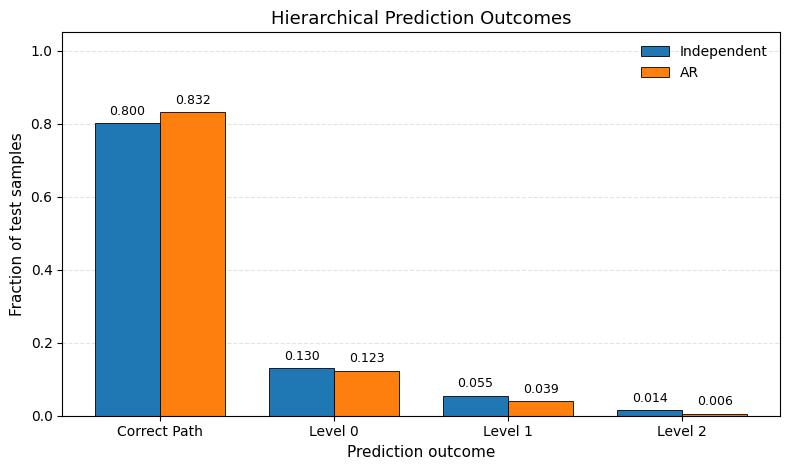


First error fractions:
Independent
  Correct Path: 0.8005
  Level 0: 0.1302
  Level 1: 0.0550
  Level 2: 0.0143
AR
  Correct Path: 0.8315
  Level 0: 0.1231
  Level 1: 0.0394
  Level 2: 0.0060


In [44]:
model_configs = {
    "Independent": {
        "csv": "outputs_local/outputs2/independent_hierarchy_final_test_fold10/predictions.csv",
        "epoch": 9,
    },
    "AR": {
        "csv": "outputs_local/outputs2/ar_hierarchy_masked_final_test_fold10/predictions.csv",
        "epoch": 9,
    },
}

data = plot_hierarchical_outcome_barplot(
    model_configs=model_configs,
    output_path="figures/first_hierarchical_error.pdf",
)

print("\nFirst error fractions:")
for model_name, fractions in data.items():
    print(model_name)
    for level, value in fractions.items():
        print(f"  {level}: {value:.4f}")

#### Confusion Matrix

In [4]:

def compute_classification_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }
def parse_path(x):
    if isinstance(x, list):
        return x

    if isinstance(x, tuple):
        return list(x)

    if pd.isna(x):
        return []

    if isinstance(x, str):
        s = x.strip()

        if s in {
            "",
            "NOT_IMPLEMENTED",
            "NOT IMPLEMENTED",
            "None",
            "nan",
        }:
            return []

        try:
            return list(ast.literal_eval(s))
        except Exception:
            return []

    return []

def labels_to_names(labels, level, hierarchy_index_dict):
    return [
        hierarchy_index_dict.get(level, {}).get(label, str(label))
        for label in labels
    ]


def load_predictions_for_epoch(predictions_csv, epoch):
    df = pd.read_csv(predictions_csv)

    if "epoch" not in df.columns:
        raise ValueError("predictions.csv must contain an 'epoch' column.")

    df = df[df["epoch"] == epoch].copy()

    if df.empty:
        raise ValueError(f"No predictions found for epoch {epoch}.")

    if "pred_path" in df.columns:
        df["pred_path_parsed"] = df["pred_path"].apply(parse_path)
    else:
        df["pred_path_parsed"] = [[] for _ in range(len(df))]

    if "target_path" in df.columns:
        df["target_path_parsed"] = df["target_path"].apply(parse_path)
    else:
        df["target_path_parsed"] = [[] for _ in range(len(df))]

    return df


def extract_level_predictions(predictions_df, level):
    """
    Extract predictions for a given level.

    For hierarchical models:
        Uses pred_path / target_path.

    For flat classifier:
        If paths are NOT_IMPLEMENTED or empty, only level 2 is supported,
        using pred_leaf and target_leaf.
    """
    y_true = []
    y_pred = []

    for _, row in predictions_df.iterrows():
        target_path = row["target_path_parsed"]
        pred_path = row["pred_path_parsed"]

        has_valid_paths = (
            len(target_path) > level
            and len(pred_path) > level
        )

        if has_valid_paths:
            y_true.append(int(target_path[level]))
            y_pred.append(int(pred_path[level]))

        else:
            # Flat classifier fallback:
            # Only meaningful for leaf-level confusion matrix.
            if level == 2:
                if "target_leaf" not in predictions_df.columns or "pred_leaf" not in predictions_df.columns:
                    raise ValueError(
                        "No valid paths found and target_leaf/pred_leaf columns are missing."
                    )

                y_true.append(int(row["target_leaf"]))
                y_pred.append(int(row["pred_leaf"]))

            else:
                continue

    return np.array(y_true), np.array(y_pred)


def compute_confusion_matrix(y_true, y_pred, labels=None):
    if labels is None:
        labels = sorted(set(y_true.tolist()) | set(y_pred.tolist()))

    label_to_idx = {label: i for i, label in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        if true_label in label_to_idx and pred_label in label_to_idx:
            i = label_to_idx[true_label]
            j = label_to_idx[pred_label]
            cm[i, j] += 1

    return cm, labels


def plot_level_confusion_matrix_from_csv(
    predictions_csv,
    hierarchy_index_dict,
    level,
    epoch,
    output_path=None,
    normalize=True,
    title=None,
    figsize=(8, 7),
    name = "Model",
):
    predictions_df = load_predictions_for_epoch(predictions_csv, epoch)

    y_true, y_pred = extract_level_predictions(
        predictions_df,
        level=level,
    )
    metrics = compute_classification_metrics(
    y_true,
    y_pred,
    )

    labels = sorted(set(y_true.tolist()) | set(y_pred.tolist()))
    label_names = labels_to_names(labels, level, hierarchy_index_dict)

    cm, labels = compute_confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
    )

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_display = np.divide(
            cm,
            row_sums,
            out=np.zeros_like(cm, dtype=float),
            where=row_sums != 0,
        )
    else:
        cm_display = cm

    if title is None:
        title = f"{name} Level {level} Confusion Matrix"

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_display)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Predicted class", fontsize=11)
    ax.set_ylabel("True class", fontsize=11)

    ax.set_xticks(np.arange(len(label_names)))
    ax.set_yticks(np.arange(len(label_names)))
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticklabels(label_names)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Normalized count" if normalize else "Count")

    fmt = ".2f" if normalize else "d"

    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            value = cm_display[i, j]
            text = format(value, fmt) if normalize else format(int(value), fmt)

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
            )

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, bbox_inches="tight")

    plt.show()

    print("\nClassification Metrics")
    print("----------------------")
    print(f"Accuracy        : {metrics['accuracy']:.4f}")
    print(f"Macro Precision : {metrics['macro_precision']:.4f}")
    print(f"Macro Recall    : {metrics['macro_recall']:.4f}")
    print(f"Macro F1        : {metrics['macro_f1']:.4f}")

    return cm, labels, metrics

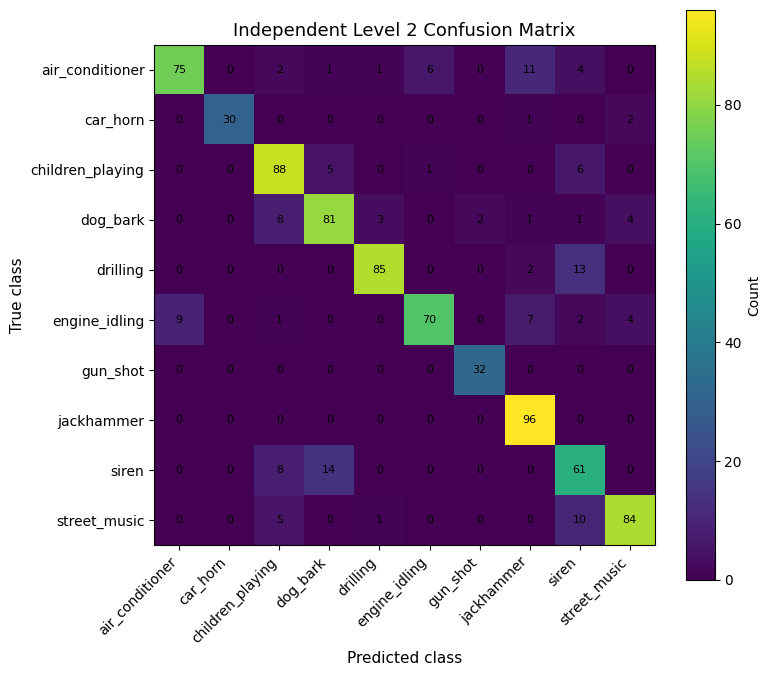


Classification Metrics
----------------------
Accuracy        : 0.8387
Macro Precision : 0.8611
Macro Recall    : 0.8527
Macro F1        : 0.8533


In [ ]:
path = "outputs_local/outputs2/independent_hierarchy_final_test_fold10"

with open(path + "/config.json", "r", encoding="utf-8") as f:
    config = json.load(f)
hiearchy_tree = get_hierarchy_tree(config["hierarchy"])
hierarchy_index_dict = hiearchy_tree.get_level_idx_to_class()

cm, labels, metrics = plot_level_confusion_matrix_from_csv(
    predictions_csv=path + "/predictions.csv",
    hierarchy_index_dict=hierarchy_index_dict,
    level=2,
    epoch=9,
    output_path="plots/nonnorm_indep_level2_confusion_matrix.png",
    normalize=False,
    name = "Independent"
)

#### Conditional Confusion Matrix

In [14]:
def filter_by_correct_level(
    predictions_epoch,
    condition_level: int,
    condition_class: int,
):
    """
    Keep samples where both target and prediction are equal to condition_class
    at condition_level.

    Example:
        condition_level=0, condition_class=1
        means target_path[0] == 1 and pred_path[0] == 1.
    """

    subset = predictions_epoch[
        predictions_epoch.apply(
            lambda r:
                len(r["target_path_parsed"]) > condition_level
                and len(r["pred_path_parsed"]) > condition_level
                and r["target_path_parsed"][condition_level] == condition_class
                and r["pred_path_parsed"][condition_level] == condition_class,
            axis=1
        )
    ].copy()

    return subset

def _labels_to_names(labels, level, hierarchy_index_dict):
    return [
        hierarchy_index_dict.get(level, {}).get(label, str(label))
        for label in labels
    ]

def plot_level_confusion_conditioned_on_correct_previous_level(
    predictions_epoch,
    target_level: int,
    condition_class: int,
    index_dict=None,
    normalize=True,
    print_metrics=True,
    figsize=(8, 7),
    name = "",
):
    """
    Plot confusion matrix for target_level, conditioned on the previous level
    being correctly predicted as condition_class.

    Example:
        target_level=1, condition_class=1
        -> plot Level 1 confusion only for samples where Level 0 was correctly predicted as class 1.

        target_level=2, condition_class=4
        -> plot Level 2 confusion only for samples where Level 1 was correctly predicted as class 4.
    """

    if target_level <= 0:
        raise ValueError(
            "target_level must be >= 1 because conditioning is done on target_level - 1."
        )

    condition_level = target_level - 1

    subset = filter_by_correct_level(
        predictions_epoch,
        condition_level=condition_level,
        condition_class=condition_class,
    )

    if subset.empty:
        raise ValueError(
            f"No samples found where Level {condition_level} was correctly "
            f"predicted as class {condition_class}."
        )

    y_true, y_pred = get_level_targets_preds(subset, target_level)

    labels = sorted(set(y_true.tolist()) | set(y_pred.tolist()))
    names = _labels_to_names(
        labels,
        level=target_level,
        index_dict=index_dict,
    )

    condition_name = str(condition_class)
    if index_dict is not None:
        condition_name = index_dict.get(condition_level, {}).get(
            condition_class,
            condition_name,
        )

    title = (
        f"{name} Level {target_level} confusion matrix\n"
        f"conditioned on correct Level {condition_level}: {condition_name}"
    )

    print(
        f"Conditioned subset: {len(subset)} samples "
        f"(Level {condition_level} = {condition_name})"
    )

    return plot_confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
        label_names=names,
        normalize=normalize,
        title=title,
        figsize=figsize,
        print_metrics=print_metrics,
    )

best epoch: 9
Conditioned on correctly predicted level 0: music (87 samples)


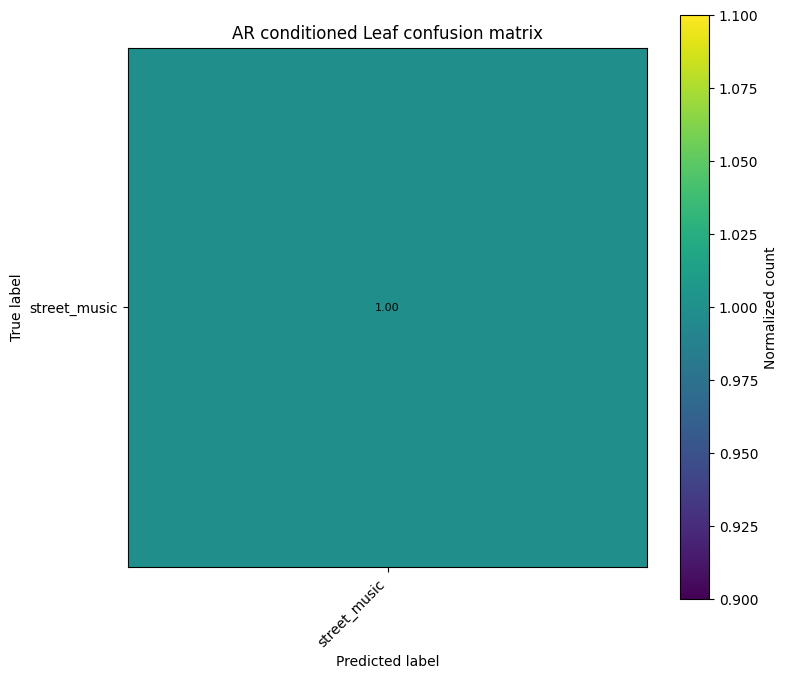


AR conditioned Leaf confusion matrix metrics
--------------------------------------------
Accuracy:          1.0000
Macro precision:   1.0000
Macro recall:      1.0000
Macro specificity: nan
Macro F1-score:    1.0000


(array([[87]]),
 [9],
 {'accuracy': np.float64(1.0),
  'macro_precision': np.float64(1.0),
  'macro_recall': np.float64(1.0),
  'macro_specificity': nan,
  'macro_f1': np.float64(1.0),
  'per_class':    class_index  tp  fp  fn  tn  precision  recall  specificity   f1
  0            0  87   0   0   0        1.0     1.0          NaN  1.0})

In [19]:
path = "outputs_local/outputs2/ar_hierarchy_masked_final_test_fold10"
_epoch = 9

exp = ExperimentView(
    path,
    epoch_range=[0, 40]
)
config_path = exp.exp_dir.joinpath("config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)
hiearchy_tree = get_hierarchy_tree(config["hierarchy"])
hierarchy_index_dict = hiearchy_tree.get_level_idx_to_class()

best_epoch = _epoch # exp.best_epoch("val_loss", "min")
print(f"best epoch: {best_epoch}")
epoch_preds = exp.preds_at(best_epoch)

plot_leaf_confusion_given_correct_level(
    epoch_preds,
    level=0, # condition on this level
    class_id=3,   # condition on this true class for level
    index_dict=hierarchy_index_dict,
    normalize=True,
    name="AR conditioned"
)

#### Hierarchy Violations

In [ ]:
def parse_path(x):
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if pd.isna(x):
        return []
    return list(ast.literal_eval(x))


def is_valid_transition(hierarchy, parent_level, parent_idx, child_idx):
    valid_children = hierarchy.get_children(
        level=parent_level,
        level_idx=parent_idx,
        output="indices",
    )

    return child_idx in valid_children


def predicted_path_validity_report(predictions_epoch, hierarchy):
    """
    Evaluates whether predicted hierarchical paths are structurally valid.

    Checks:
        pred_path[1] is child of pred_path[0]
        pred_path[2] is child of pred_path[1]

    This is independent of whether the prediction is correct.
    """

    df = predictions_epoch.copy()

    if "pred_path_parsed" not in df.columns:
        df["pred_path_parsed"] = df["pred_path"].apply(parse_path)

    rows = []

    for _, row in df.iterrows():
        pred_path = row["pred_path_parsed"]

        violation_l0_l1 = False
        violation_l1_l2 = False

        if len(pred_path) < 3:
            violation_l0_l1 = True
            violation_l1_l2 = True
        else:
            pred_l0, pred_l1, pred_l2 = pred_path

            violation_l0_l1 = not is_valid_transition(
                hierarchy,
                parent_level=0,
                parent_idx=pred_l0,
                child_idx=pred_l1,
            )

            violation_l1_l2 = not is_valid_transition(
                hierarchy,
                parent_level=1,
                parent_idx=pred_l1,
                child_idx=pred_l2,
            )

        has_violation = violation_l0_l1 or violation_l1_l2

        rows.append({
            "sample_idx": row.get("sample_idx", None),
            "pred_path": pred_path,
            "violation_L0_to_L1": violation_l0_l1,
            "violation_L1_to_L2": violation_l1_l2,
            "has_violation": has_violation,
        })

    violation_df = pd.DataFrame(rows)

    total_samples = len(violation_df)
    total_violating_samples = int(violation_df["has_violation"].sum())

    report = {
        "total_samples": total_samples,
        "total_violating_samples": total_violating_samples,
        "violation_rate": total_violating_samples / total_samples,
        "violations_L0_to_L1": int(violation_df["violation_L0_to_L1"].sum()),
        "violations_L1_to_L2": int(violation_df["violation_L1_to_L2"].sum()),
        "violation_rate_L0_to_L1": violation_df["violation_L0_to_L1"].mean(),
        "violation_rate_L1_to_L2": violation_df["violation_L1_to_L2"].mean(),
        "details": violation_df,
    }

    return report



In [22]:
path = "outputs_local/outputs2/independent_hierarchy_final_test_fold10"
_epoch = 9

exp = ExperimentView(
    path,
    epoch_range=[0, 40]
)
config_path = exp.exp_dir.joinpath("config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)
hiearchy_tree = get_hierarchy_tree(config["hierarchy"])
hierarchy_index_dict = hiearchy_tree.get_level_idx_to_class()

best_epoch = _epoch # exp.best_epoch("val_loss", "min")
print(f"best epoch: {best_epoch}")
epoch_preds = exp.preds_at(best_epoch)

report = predicted_path_validity_report(
    predictions_epoch=epoch_preds,
    hierarchy=hiearchy_tree,
)

print("Path validity report")
print("--------------------")
print(f"Total samples:              {report['total_samples']}")
print(f"Total violating samples:    {report['total_violating_samples']}")
print(f"Violation rate:             {report['violation_rate']:.4f}")
print(f"L0 → L1 violations:         {report['violations_L0_to_L1']}")
print(f"L1 → L2 violations:         {report['violations_L1_to_L2']}")
print(f"L0 → L1 violation rate:     {report['violation_rate_L0_to_L1']:.4f}")
print(f"L1 → L2 violation rate:     {report['violation_rate_L1_to_L2']:.4f}")

violations = report["details"]
violations[violations["has_violation"]]

best epoch: 9
Path validity report
--------------------
Total samples:              837
Total violating samples:    79
Violation rate:             0.0944
L0 → L1 violations:         50
L1 → L2 violations:         49
L0 → L1 violation rate:     0.0597
L1 → L2 violation rate:     0.0585


,sample_idx,pred_path,violation_L0_to_L1,violation_L1_to_L2,has_violation
25,25,"[2, 4, 2]",False,True,True
50,50,"[0, 0, 3]",False,True,True
95,95,"[0, 3, 3]",True,True,True
111,111,"[1, 4, 7]",True,False,True
125,125,"[1, 4, 8]",True,True,True
...,...,...,...,...,...
725,725,"[1, 1, 4]",True,True,True
741,741,"[1, 2, 8]",False,True,True
771,771,"[1, 3, 1]",False,True,True
802,802,"[0, 3, 3]",True,True,True


#### Least Common Ancestor

In [3]:
def parse_path(x):
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if pd.isna(x):
        return []
    return list(ast.literal_eval(x))


def get_lca_level(target_path, pred_path):
    """
    Returns:
        1  -> same Level 1 parent, close error
        0  -> same Level 0 parent, moderate error
        -1 -> only root shared, severe error
        None -> paths are identical
    """
    if target_path == pred_path:
        return None

    lca_level = -1  # root

    for level, (t, p) in enumerate(zip(target_path, pred_path)):
        if t == p:
            lca_level = level
        else:
            break

    return lca_level


def lca_level_to_name(lca_level, target_path, hierarchy):
    if lca_level is None:
        return "correct_path"

    if lca_level == -1:
        return "root"

    return hierarchy.get_name_from_level_idx(
        level=lca_level,
        level_idx=target_path[lca_level],
    )


def hierarchical_distance_from_lca(lca_level, leaf_level=2):
    """
    For leaf-level predictions in a depth-3 hierarchy:
        LCA Level 1 -> distance 2
        LCA Level 0 -> distance 4
        LCA root    -> distance 6
    """
    if lca_level is None:
        return 0

    if lca_level == -1:
        return 2 * (leaf_level + 1)

    return 2 * (leaf_level - lca_level)


def lca_error_analysis(
    predictions_epoch,
    hierarchy,
    require_valid_paths=True,
):
    df = predictions_epoch.copy()

    if "pred_path_parsed" not in df.columns:
        df["pred_path_parsed"] = df["pred_path"].apply(parse_path)

    if "target_path_parsed" not in df.columns:
        df["target_path_parsed"] = df["target_path"].apply(parse_path)

    rows = []

    total_samples = len(df)
    total_wrong_leaf_predictions = 0
    invalid_wrong_leaf_predictions = 0
    valid_wrong_leaf_predictions = 0

    for _, row in df.iterrows():
        pred_path = row["pred_path_parsed"]
        target_path = row["target_path_parsed"]

        if len(pred_path) < 3 or len(target_path) < 3:
            continue

        # Only wrong leaf predictions are relevant for LCA error severity
        if pred_path[-1] == target_path[-1]:
            continue

        total_wrong_leaf_predictions += 1

        valid_l0_l1 = pred_path[1] in hierarchy.get_children(
            level=0,
            level_idx=pred_path[0],
            output="indices",
        )

        valid_l1_l2 = pred_path[2] in hierarchy.get_children(
            level=1,
            level_idx=pred_path[1],
            output="indices",
        )

        is_valid_pred_path = valid_l0_l1 and valid_l1_l2

        if not is_valid_pred_path:
            invalid_wrong_leaf_predictions += 1

            if require_valid_paths:
                continue

        valid_wrong_leaf_predictions += int(is_valid_pred_path)

        lca_level = get_lca_level(target_path, pred_path)
        lca_name = lca_level_to_name(lca_level, target_path, hierarchy)
        distance = hierarchical_distance_from_lca(lca_level, leaf_level=2)

        if lca_level == 1:
            severity = "close"
        elif lca_level == 0:
            severity = "moderate"
        elif lca_level == -1:
            severity = "severe"
        else:
            severity = "unknown"

        rows.append({
            "sample_idx": row.get("sample_idx", None),
            "target_path": target_path,
            "pred_path": pred_path,
            "target_leaf": target_path[-1],
            "pred_leaf": pred_path[-1],
            "is_valid_pred_path": is_valid_pred_path,
            "lca_level": lca_level,
            "lca_name": lca_name,
            "hierarchical_distance": distance,
            "severity": severity,
        })

    details = pd.DataFrame(rows)

    invalid_wrong_leaf_rate = (
        invalid_wrong_leaf_predictions / total_wrong_leaf_predictions
        if total_wrong_leaf_predictions > 0
        else np.nan
    )

    valid_wrong_leaf_rate = (
        valid_wrong_leaf_predictions / total_wrong_leaf_predictions
        if total_wrong_leaf_predictions > 0
        else np.nan
    )

    if details.empty:
        return {
            "total_samples": total_samples,
            "total_wrong_leaf_predictions": total_wrong_leaf_predictions,
            "valid_wrong_leaf_predictions": valid_wrong_leaf_predictions,
            "invalid_wrong_leaf_predictions": invalid_wrong_leaf_predictions,
            "invalid_wrong_leaf_rate": invalid_wrong_leaf_rate,
            "valid_wrong_leaf_rate": valid_wrong_leaf_rate,
            "average_lca_level": np.nan,
            "average_hierarchical_distance": np.nan,
            "lca_distribution": pd.DataFrame(),
            "details": details,
        }

    lca_distribution = (
        details["lca_level"]
        .value_counts()
        .rename_axis("lca_level")
        .reset_index(name="count")
        .sort_values("lca_level")
    )

    lca_distribution["fraction_of_analyzed"] = (
        lca_distribution["count"] / len(details)
    )

    lca_distribution["fraction_of_all_wrong_leaf"] = (
        lca_distribution["count"] / total_wrong_leaf_predictions
        if total_wrong_leaf_predictions > 0
        else np.nan
    )

    lca_distribution["lca_label"] = lca_distribution["lca_level"].map(
        {-1: "root", 0: "Level 0", 1: "Level 1"}
    )

    report = {
        "total_samples": total_samples,
        "total_wrong_leaf_predictions": total_wrong_leaf_predictions,
        "valid_wrong_leaf_predictions": valid_wrong_leaf_predictions,
        "invalid_wrong_leaf_predictions": invalid_wrong_leaf_predictions,
        "invalid_wrong_leaf_rate": invalid_wrong_leaf_rate,
        "valid_wrong_leaf_rate": valid_wrong_leaf_rate,
        "num_analyzed_predictions": len(details),
        "average_lca_level": details["lca_level"].mean(),
        "average_hierarchical_distance": details["hierarchical_distance"].mean(),
        "lca_distribution": lca_distribution,
        "details": details,
    }

    return report

In [5]:
path = "outputs_local/outputs2/ar_hierarchy_masked_final_test_fold10"
_epoch = 9

exp = ExperimentView(
    path,
    epoch_range=[0, 40]
)
config_path = exp.exp_dir.joinpath("config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)
hiearchy_tree = get_hierarchy_tree(config["hierarchy"])
hierarchy_index_dict = hiearchy_tree.get_level_idx_to_class()

best_epoch = _epoch # exp.best_epoch("val_loss", "min")
print(f"best epoch: {best_epoch}")
epoch_preds = exp.preds_at(best_epoch)


report = lca_error_analysis(
    predictions_epoch=epoch_preds,
    hierarchy=hiearchy_tree,
    require_valid_paths=True,
)

print("LCA error analysis")
print("------------------")
print(f"Total samples:                 {report['total_samples']}")
print(f"Total wrong leaf predictions:  {report['total_wrong_leaf_predictions']}")
print(f"Valid wrong leaf predictions:  {report['valid_wrong_leaf_predictions']}")
print(f"Invalid wrong leaf predictions:{report['invalid_wrong_leaf_predictions']}")
print(f"Invalid wrong leaf rate:       {report['invalid_wrong_leaf_rate']:.4f}")
print(f"Analyzed predictions:          {report['num_analyzed_predictions']}")
print(f"Average LCA level:             {report['average_lca_level']:.4f}")
print(f"Average hierarchical distance: {report['average_hierarchical_distance']:.4f}")

print("\nLCA distribution:")
print(report["lca_distribution"].to_string(index=False))

report["details"].sort_values("hierarchical_distance", ascending=False).head(10)

best epoch: 9
LCA error analysis
------------------
Total samples:                 837
Total wrong leaf predictions:  141
Valid wrong leaf predictions:  141
Invalid wrong leaf predictions:0
Invalid wrong leaf rate:       0.0000
Analyzed predictions:          141
Average LCA level:             -0.6950
Average hierarchical distance: 5.3901

LCA distribution:
 lca_level  count  fraction_of_analyzed  fraction_of_all_wrong_leaf lca_label
        -1    103              0.730496                    0.730496      root
         0     33              0.234043                    0.234043   Level 0
         1      5              0.035461                    0.035461   Level 1


,sample_idx,target_path,pred_path,target_leaf,pred_leaf,is_valid_pred_path,lca_level,lca_name,hierarchical_distance,severity
0,25,"[2, 5, 0]","[0, 0, 2]",0,2,True,-1,root,6,severe
1,26,"[3, 7, 9]","[2, 4, 4]",9,4,True,-1,root,6,severe
2,28,"[0, 1, 3]","[3, 7, 9]",3,9,True,-1,root,6,severe
3,33,"[0, 1, 3]","[1, 2, 1]",3,1,True,-1,root,6,severe
4,38,"[0, 1, 3]","[3, 7, 9]",3,9,True,-1,root,6,severe
6,48,"[3, 7, 9]","[0, 0, 2]",9,2,True,-1,root,6,severe
8,66,"[3, 7, 9]","[0, 0, 2]",9,2,True,-1,root,6,severe
11,74,"[0, 1, 3]","[3, 7, 9]",3,9,True,-1,root,6,severe
9,69,"[3, 7, 9]","[1, 3, 8]",9,8,True,-1,root,6,severe
17,147,"[1, 2, 5]","[0, 0, 2]",5,2,True,-1,root,6,severe


#### Hierarchical Confusions

In [30]:
def make_hierarchical_confusion_table(
    predictions_epoch: pd.DataFrame,
    index_dict: Optional[Dict[int, Dict[int, str]]] = None,
) -> pd.DataFrame:
    rows = []

    for _, row in predictions_epoch.iterrows():
        target_path = row["target_path_parsed"]
        pred_path = row["pred_path_parsed"]

        true_parts = []
        pred_parts = []

        for level, (target_idx, pred_idx) in enumerate(zip(target_path, pred_path)):
            if index_dict is not None and level in index_dict:
                true_parts.append(index_dict[level].get(target_idx, str(target_idx)))
                pred_parts.append(index_dict[level].get(pred_idx, str(pred_idx)))
            else:
                true_parts.append(str(target_idx))
                pred_parts.append(str(pred_idx))

        rows.append({
            "true_path": " / ".join(true_parts),
            "pred_path": " / ".join(pred_parts),
        })

    table = (
        pd.DataFrame(rows)
        .value_counts(["true_path", "pred_path"])
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    total = table["count"].sum()
    table["fraction"] = table["count"] / total

    return table


def plot_top_hierarchical_confusions(
    predictions_epoch: pd.DataFrame,
    index_dict: Optional[Dict[int, Dict[int, str]]] = None,
    top_k: int = 20,
    only_errors: bool = True,
    figsize=(12, 7),
    normalize: bool = False,
    output_path: Optional[str] = None,
    name = ""
):
    table = make_hierarchical_confusion_table(
        predictions_epoch,
        index_dict=index_dict,
    )

    if only_errors:
        table = table[table["true_path"] != table["pred_path"]].copy()

    if table.empty:
        print("No hierarchical confusions to show.")
        return table

    total_count = table["count"].sum()

    table["error_fraction"] = table["count"] / total_count

    print("\nHierarchical confusion table")
    print("----------------------------")
    print(table.to_string(index=False))

    top = table.head(top_k).copy()
    top["label"] = top["true_path"] + "  →  " + top["pred_path"]

    value_col = "error_fraction" if normalize else "count"
    xlabel = "Fraction of errors" if normalize else "Count"

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.barh(
        top["label"][::-1],
        top[value_col][::-1],
        edgecolor="black",
        linewidth=0.6,
    )

    ax.set_title(
        f"{name} Top {min(top_k, len(top))} hierarchical path confusions",
        fontsize=13,
    )
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("True path → predicted path", fontsize=11)

    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    for bar in bars:
        width = bar.get_width()

        label = f"{width:.3f}" if normalize else f"{int(width)}"

        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f" {label}",
            va="center",
            fontsize=9,
        )

    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")

    plt.show()

    return table

best epoch: 9

Hierarchical confusion table
----------------------------
                                  true_path                                           pred_path  count  fraction  error_fraction
 mechanical / ventilation / air_conditioner              mechanical / construction / jackhammer     11  0.013142        0.065868
           vehicle / vehicle_signal / siren                    human_animal / animal / dog_bark      9  0.010753        0.053892
           vehicle / vehicle_signal / siren             human_animal / human / children_playing      8  0.009558        0.047904
           human_animal / animal / dog_bark             human_animal / human / children_playing      8  0.009558        0.047904
            music / recorded / street_music                    vehicle / vehicle_signal / siren      7  0.008363        0.041916
vehicle / vehicle_operation / engine_idling          mechanical / ventilation / air_conditioner      7  0.008363        0.041916
 mechanical / ventilatio

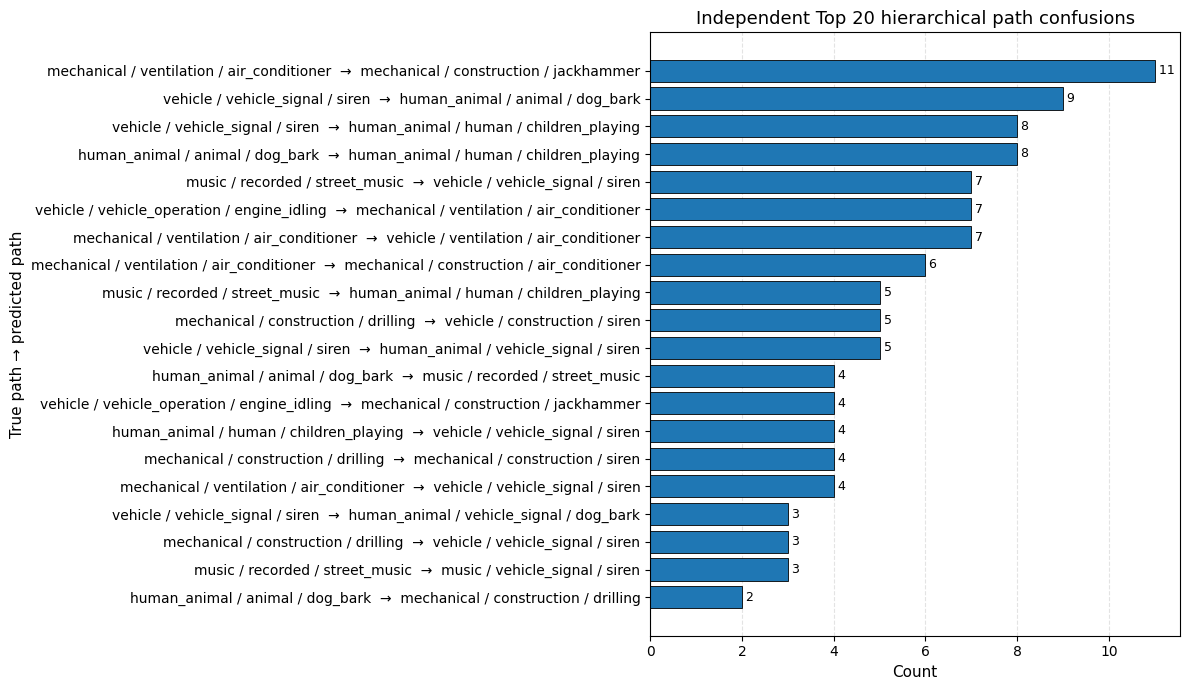

In [33]:
path = "outputs_local/outputs2/independent_hierarchy_final_test_fold10"
_epoch = 9

exp = ExperimentView(
    path,
    epoch_range=[0, 40]
)
config_path = exp.exp_dir.joinpath("config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)
hiearchy_tree = get_hierarchy_tree(config["hierarchy"])
hierarchy_index_dict = hiearchy_tree.get_level_idx_to_class()

best_epoch = _epoch # exp.best_epoch("val_loss", "min")
print(f"best epoch: {best_epoch}")
epoch_preds = exp.preds_at(best_epoch)


confusion_table = plot_top_hierarchical_confusions(
    predictions_epoch=epoch_preds,
    index_dict=hierarchy_index_dict,
    top_k=20,
    only_errors=True,
    normalize=False,
    output_path="plots/top_hierarchical_confusions.pdf",
    name = "Independent"
)

#### Class-Wise Hierarchical Error profile

In [28]:
def parse_path(x):
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if pd.isna(x):
        return []
    return list(ast.literal_eval(x))


def is_valid_pred_path(pred_path, hierarchy):
    if len(pred_path) < 3:
        return False

    valid_l0_l1 = pred_path[1] in hierarchy.get_children(
        level=0,
        level_idx=pred_path[0],
        output="indices",
    )

    valid_l1_l2 = pred_path[2] in hierarchy.get_children(
        level=1,
        level_idx=pred_path[1],
        output="indices",
    )

    return valid_l0_l1 and valid_l1_l2


def get_lca_level(target_path, pred_path):
    if target_path == pred_path:
        return None

    lca_level = -1  # root

    for level, (t, p) in enumerate(zip(target_path, pred_path)):
        if t == p:
            lca_level = level
        else:
            break

    return lca_level


def hierarchical_distance_from_lca(lca_level, leaf_level=2):
    if lca_level is None:
        return 0

    if lca_level == -1:
        return 2 * (leaf_level + 1)

    return 2 * (leaf_level - lca_level)


def classwise_hierarchical_error_profile(
    predictions_epoch,
    hierarchy,
    index_dict=None,
    distance_over="wrong_valid",
):
    """
    Creates class-wise hierarchical error profile table.

    distance_over:
        "wrong_valid" -> mean distance only over wrong predictions with valid predicted paths.
        "all_valid"   -> mean distance over all predictions with valid predicted paths.
    """

    df = predictions_epoch.copy()

    if "pred_path_parsed" not in df.columns:
        df["pred_path_parsed"] = df["pred_path"].apply(parse_path)

    if "target_path_parsed" not in df.columns:
        df["target_path_parsed"] = df["target_path"].apply(parse_path)

    rows = []

    for _, row in df.iterrows():
        target_path = row["target_path_parsed"]
        pred_path = row["pred_path_parsed"]

        if len(target_path) < 3 or len(pred_path) < 3:
            continue

        true_leaf = int(target_path[-1])
        pred_leaf = int(pred_path[-1])

        correct_leaf = true_leaf == pred_leaf
        valid_pred_path = is_valid_pred_path(pred_path, hierarchy)

        lca_level = get_lca_level(target_path, pred_path)
        distance = hierarchical_distance_from_lca(lca_level, leaf_level=2)

        rows.append({
            "true_leaf": true_leaf,
            "pred_leaf": pred_leaf,
            "correct_leaf": correct_leaf,
            "valid_pred_path": valid_pred_path,
            "lca_level": lca_level,
            "hierarchical_distance": distance,
        })

    analysis_df = pd.DataFrame(rows)

    result_rows = []

    all_true_leaves = sorted(analysis_df["true_leaf"].unique())

    for true_leaf in all_true_leaves:
        class_df = analysis_df[analysis_df["true_leaf"] == true_leaf].copy()

        support = len(class_df)
        leaf_accuracy = class_df["correct_leaf"].mean()

        wrong_valid = class_df[
            (~class_df["correct_leaf"]) &
            (class_df["valid_pred_path"])
        ].copy()

        all_valid = class_df[class_df["valid_pred_path"]].copy()

        if distance_over == "wrong_valid":
            distance_df = wrong_valid
        elif distance_over == "all_valid":
            distance_df = all_valid
        else:
            raise ValueError("distance_over must be 'wrong_valid' or 'all_valid'")

        mean_distance = (
            distance_df["hierarchical_distance"].mean()
            if not distance_df.empty
            else np.nan
        )

        root_lca_fraction = (
            (wrong_valid["lca_level"] == -1).mean()
            if not wrong_valid.empty
            else np.nan
        )

        severe_df = wrong_valid[wrong_valid["lca_level"] == -1].copy()

        if severe_df.empty:
            most_common_severe_confusion = None
            most_common_severe_count = 0
        else:
            pred_counts = severe_df["pred_leaf"].value_counts()
            most_common_pred_leaf = int(pred_counts.idxmax())
            most_common_severe_count = int(pred_counts.max())

            true_name = hierarchy.get_name_from_level_idx(
                level=2,
                level_idx=true_leaf,
            )
            pred_name = hierarchy.get_name_from_level_idx(
                level=2,
                level_idx=most_common_pred_leaf,
            )

            most_common_severe_confusion = f"{true_name} → {pred_name}"

        true_leaf_name = hierarchy.get_name_from_level_idx(
            level=2,
            level_idx=true_leaf,
        )

        result_rows.append({
            "true_leaf": true_leaf_name,
            "support": support,
            "leaf_accuracy": leaf_accuracy,
            "wrong_valid_count": len(wrong_valid),
            "mean_hierarchical_distance": mean_distance,
            "root_lca_fraction": root_lca_fraction,
            "most_common_severe_confusion": most_common_severe_confusion,
            "most_common_severe_count": most_common_severe_count,
        })

    result_table = pd.DataFrame(result_rows)

    result_table = result_table.sort_values(
        ["root_lca_fraction", "mean_hierarchical_distance"],
        ascending=False,
        na_position="last",
    ).reset_index(drop=True)

    return result_table, analysis_df

In [29]:
path = "outputs_local/outputs2/independent_hierarchy_final_test_fold10"
_epoch = 9

exp = ExperimentView(
    path,
    epoch_range=[0, 40]
)
config_path = exp.exp_dir.joinpath("config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)
hiearchy_tree = get_hierarchy_tree(config["hierarchy"])
hierarchy_index_dict = hiearchy_tree.get_level_idx_to_class()

best_epoch = _epoch # exp.best_epoch("val_loss", "min")
print(f"best epoch: {best_epoch}")
epoch_preds = exp.preds_at(best_epoch)

profile_table, per_sample_df = classwise_hierarchical_error_profile(
    predictions_epoch=epoch_preds,
    hierarchy=hiearchy_tree,
    distance_over="wrong_valid",
)

print(profile_table.to_string(index=False))
print(
    profile_table.to_latex(
        index=False,
        float_format="%.3f",
    )
)

best epoch: 9
       true_leaf  support  leaf_accuracy  wrong_valid_count  mean_hierarchical_distance  root_lca_fraction    most_common_severe_confusion  most_common_severe_count
        car_horn       33       0.909091                  1                    6.000000           1.000000           car_horn → jackhammer                         1
   engine_idling       93       0.752688                 13                    6.000000           1.000000 engine_idling → air_conditioner                         7
           siren       83       0.734940                 17                    6.000000           1.000000                siren → dog_bark                         9
    street_music      100       0.840000                 12                    6.000000           1.000000            street_music → siren                         7
children_playing      100       0.880000                  5                    5.600000           0.800000        children_playing → siren                       